# VizWiz Dataset Analysis

## Importing Required Libraries

In [2]:
# Importing OS for system operations, numpy and pandas for data manipulation
import os
import numpy as np 
import pandas as pd

# Importing tqdm to track computation progress
from tqdm.notebook import tqdm

# For data visualization, we will use matplotlib, wordcloud
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from wordcloud import WordCloud, STOPWORDS
import textwrap

# For data preprocessing, we will use Counter, train_test_split, Levenshtein distance, Python Image Library and OneHotEncoder
from collections import Counter
from PIL import Image

# For saving and loading the preprocessed data, we will use pickle
import pickle

# Importing json for results formatting which will be uploaded for evaluation
import json

## Configuring the Notebook

In [3]:
# Configuring the paths for the dataset
INPUT_PATH = '/kaggle/input/vizwiz-2023-edition'
ANNOTATIONS_PATH = INPUT_PATH + '/Annotations'
TRAIN_PATH = INPUT_PATH + '/train/train'
VALIDATION_PATH = INPUT_PATH + '/val/val'
TEST_PATH = INPUT_PATH + '/test/test'
ANNOTATIONS_TRAIN_PATH = ANNOTATIONS_PATH + '/train.json'
ANNOTATIONS_VAL_PATH = ANNOTATIONS_PATH + '/val.json'
ANNOTATIONS_TEST_PATH = ANNOTATIONS_PATH + '/test.json'
OUTPUT_PATH = '/kaggle/working/'

## Utility Functions

In [24]:
def read_dataframe(path):
    """
    Reads the JSON file and returns a dataframe with the required columns (image, question, answers, answer_type, answerable)

    Parameters:
        path (str): Path to the JSON file

    Returns:
        df (pandas.DataFrame): Dataframe with the required columns
    """
    df = pd.read_json(path)
    return df

def plot_wordclouds(fig_name, train_df, val_df, test_df, column):
    """
    Plots the wordclouds of the given column of each dataframe

    Parameters:
        train_df, val_df, test_df (pandas.DataFrame): Dataframe to be used
        column (str): Column to be plotted
    
    Returns:
        None
    """
    def generate_text(dataframe, column, custom_stopwords):
        return " ".join([
            sentence.lower()
            for sentence in dataframe[column]
        ])
    
    # Define stopwords excluding question words
    question_words = {"what", "where", "how", "when", "who", "why", "which", "whom", "is", "will", "are", "was", "were"}
    custom_stopwords = STOPWORDS.difference(question_words)

    # Prepare texts
    train_text = generate_text(train_df, column, custom_stopwords)
    val_text = generate_text(val_df, column, custom_stopwords)
    test_text = generate_text(test_df, column, custom_stopwords)

    # Create wordclouds
    wordclouds = [
        WordCloud(width=400, height=400, background_color='white', colormap='plasma',
                  stopwords=custom_stopwords).generate(text)
        for text in [train_text, val_text, test_text]
    ]

    titles = ['Training', 'Validation', 'Test']

    # Plot side-by-side
    plt.figure(figsize=(15, 5))
    for i, (wc, title) in enumerate(zip(wordclouds, titles)):
        plt.subplot(1, 3, i + 1)
        plt.imshow(wc, interpolation='bilinear')
        plt.axis("off")
        plt.title(title, fontsize=18)

    plt.tight_layout()
    plt.savefig(fig_name, bbox_inches='tight', dpi=300)
    plt.show()

def plot_top_questions_all(fig_name, train_df, val_df, test_df, column='question', top_n=10, sample_size=None):
    """
    Plots horizontal bar charts of the top_n most frequent full questions
    in train, validation, and test DataFrames.

    Parameters:
    - train_df, val_df, test_df: pandas DataFrames
    - column: name of the column containing the questions
    - top_n: number of most frequent questions to show
    - sample_size: optional sample size per dataframe
    """
    def get_question_counts(df):
        if sample_size:
            df = df.sample(n=sample_size, random_state=42)
        return (
            df[column]
            .dropna()
            .str.strip()
            .str.lower()
            .value_counts()
            .head(top_n)
        )

    # Get counts
    datasets = [train_df, val_df, test_df]
    titles = ['Training', 'Validation', 'Test']
    counts_list = [get_question_counts(df) for df in datasets]

    # Plot
    plt.figure(figsize=(15, top_n * 0.5))
    for i, (counts, title) in enumerate(zip(counts_list, titles)):
        plt.subplot(1, 3, i + 1)
        counts.sort_values().plot(kind='barh', color='skyblue')
        plt.title(f"{title} Set", fontsize=14)
        plt.xlabel('Frequency', fontsize=12)
        plt.ylabel('Question', fontsize=12)
        plt.tick_params(axis='both', which='major', labelsize=12)
        plt.tight_layout()

    plt.savefig(fig_name, bbox_inches='tight', dpi=300)
    plt.show()

def plot_pie_train_val(fig_name, train_df, val_df, column):
    """
    Plots side-by-side pie charts for the given column in train and validation DataFrames.

    Parameters:
        train_df (pandas.DataFrame): Training DataFrame
        val_df (pandas.DataFrame): Validation DataFrame
        column (str): Column to be plotted

    Returns:
        None
    """
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    for ax, df, title in zip(axes, [train_df, val_df], ['Training Set', 'Validation Set']):
        value_counts = df[column].value_counts()
        ax.pie(
            value_counts,
            labels=value_counts.index,
            autopct='%1.1f%%',
            startangle=140,
            textprops={'fontsize': 10}
        )
        ax.set_title(f"{title} - {column}", fontsize=18)

    plt.tight_layout()
    plt.savefig(fig_name, bbox_inches='tight', dpi=300)
    plt.show()

def get_distinct_answers(dataframe):
    """
    Returns the set of lowercase distinct answers in the dataframe.

    Parameters:
        dataframe (pandas.DataFrame): Dataframe to be explored

    Returns:
        unique_answers_set: Set of lowercase distinct answers
    """
    unique_answers_set = set()
    for row in dataframe['answers']:
        for answer_map in row:
            answer = answer_map['answer'].strip().lower()
            unique_answers_set.add(answer)
    return unique_answers_set

def plot_answer_wordclouds(fig_name, train_df, val_df):
    """
    Plots wordclouds for distinct lowercase answers in train and val DataFrames side by side.

    Parameters:
        train_df (pandas.DataFrame): Training set
        val_df (pandas.DataFrame): Validation set
    """
    # Get distinct lowercase answers
    train_answers = get_distinct_answers(train_df)
    val_answers = get_distinct_answers(val_df)

    # Convert sets to space-joined strings
    train_text = " ".join(train_answers)
    val_text = " ".join(val_answers)

    # Generate word clouds
    wordclouds = [
        WordCloud(width=400, height=400, background_color='white', colormap='plasma').generate(text)
        for text in [train_text, val_text]
    ]

    titles = ['Training Answers', 'Validation Answers']

    # Plot
    plt.figure(figsize=(8, 4))
    for i, (wc, title) in enumerate(zip(wordclouds, titles)):
        plt.subplot(1, 2, i + 1)
        plt.imshow(wc, interpolation='bilinear')
        plt.axis("off")
        plt.title(title, fontsize=18)

    plt.tight_layout()
    plt.savefig(fig_name, bbox_inches='tight', dpi=300)
    plt.show()

def show_answer_type_examples(fig_name, df, image_base_path, random_state=42, wrap_width=40):
    """
    Displays one randomly sampled image per answer type with the corresponding wrapped question as title.

    Parameters:
        df (pandas.DataFrame): Dataframe with 'answer_type', 'image', and 'question' columns
        image_base_path (str): Path to the image directory
        random_state (int): Random seed for reproducibility
        wrap_width (int): Max characters per line for wrapping question text

    Returns:
        None
    """
    # Define answer types to show
    answer_types = ['other', 'unanswerable', 'yes/no', 'number']
    filtered_dfs = {
        ans_type: df[df['answer_type'] == ans_type].sample(n=1, random_state=random_state)
        for ans_type in answer_types
        if not df[df['answer_type'] == ans_type].empty
    }

    plt.figure(figsize=(4 * len(filtered_dfs), 5))

    for i, (ans_type, sub_df) in enumerate(filtered_dfs.items(), 1):
        image_path = f"{image_base_path}/{sub_df.iloc[0]['image']}"
        question = sub_df.iloc[0]['question']
        image = Image.open(image_path)

        # Wrap question to multiple lines
        wrapped_question = "\n".join(textwrap.wrap(question, width=wrap_width))

        ax = plt.subplot(1, len(filtered_dfs), i)
        ax.imshow(image)
        ax.set_title(f"{ans_type.title()}:\n{wrapped_question}", fontsize=14)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(fig_name, bbox_inches='tight', dpi=300)
    plt.show()

## Creating Dataframes

In [17]:
train_df = read_dataframe(ANNOTATIONS_TRAIN_PATH)
val_df = read_dataframe(ANNOTATIONS_VAL_PATH)
test_df = read_dataframe(ANNOTATIONS_TEST_PATH)

In [18]:
train_df.head()

,image,question,answers,answer_type,answerable
0,VizWiz_train_00000000.jpg,What's the name of this product?,"[{'answer_confidence': 'yes', 'answer': 'basil...",other,1
1,VizWiz_train_00000001.jpg,Can you tell me what is in this can please?,"[{'answer_confidence': 'yes', 'answer': 'soda'...",other,1
2,VizWiz_train_00000002.jpg,Is this enchilada sauce or is this tomatoes? ...,"[{'answer_confidence': 'yes', 'answer': 'these...",other,1
3,VizWiz_train_00000003.jpg,What is the captcha on this screenshot?,"[{'answer_confidence': 'yes', 'answer': 't36m'...",other,1
4,VizWiz_train_00000004.jpg,What is this item?,"[{'answer_confidence': 'yes', 'answer': 'solar...",other,1


In [19]:
val_df.head()

,image,question,answers,answer_type,answerable
0,VizWiz_val_00000000.jpg,Ok. There is another picture I hope it is a be...,"[{'answer': 'unanswerable', 'answer_confidence...",unanswerable,0
1,VizWiz_val_00000001.jpg,Can you tell me what this medicine is please?,"[{'answer': 'no', 'answer_confidence': 'yes'},...",other,1
2,VizWiz_val_00000002.jpg,What is the title of this book?,"[{'answer': 'dog years', 'answer_confidence': ...",other,1
3,VizWiz_val_00000003.jpg,Which one is the blue one?,"[{'answer': 'right', 'answer_confidence': 'yes...",other,1
4,VizWiz_val_00000004.jpg,What does the arrow say?,"[{'answer': 'unanswerable', 'answer_confidence...",unanswerable,0


In [20]:
test_df.head()

,image,question
0,VizWiz_test_00000000.jpg,What is this? And what color is it?
1,VizWiz_test_00000001.jpg,What is this?
2,VizWiz_test_00000002.jpg,Has this oven gotten up to four hundred fifty ...
3,VizWiz_test_00000003.jpg,What is this?
4,VizWiz_test_00000004.jpg,What is this?


## Exploratory Data Analysis

### Analysis of Questions

/tmp/ipykernel_35/2905580399.py:98: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_35/2905580399.py:98: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


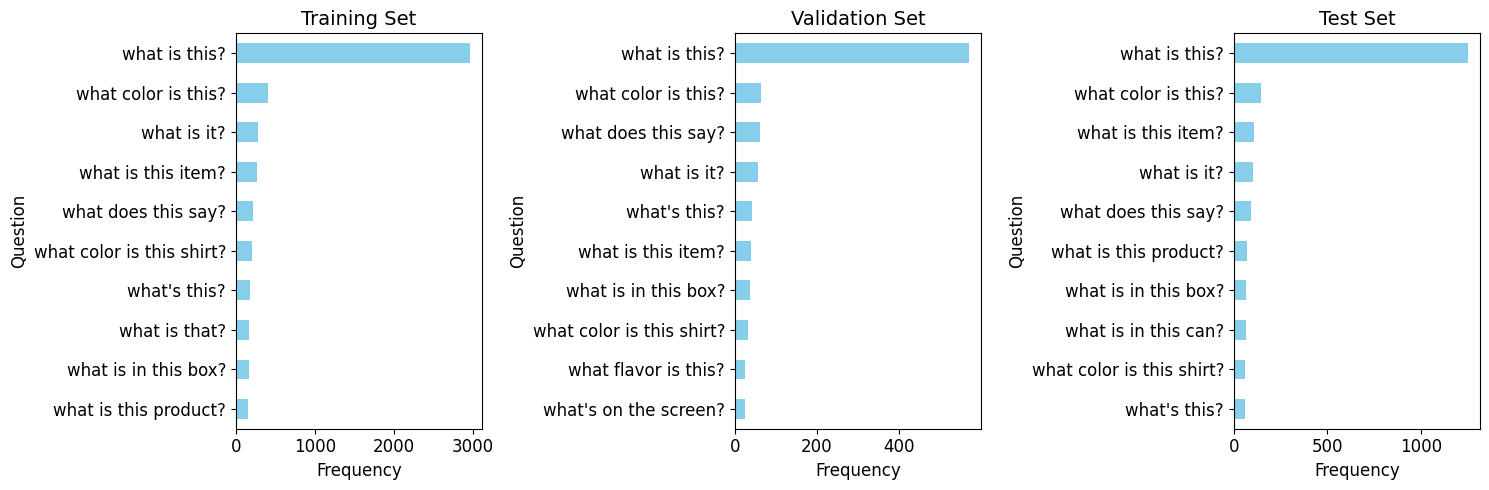

In [21]:
# Plot frequency of top 10 questions for each dataframe
plot_top_questions_all("top_10_questions", train_df, val_df, test_df, column='question', top_n=10)

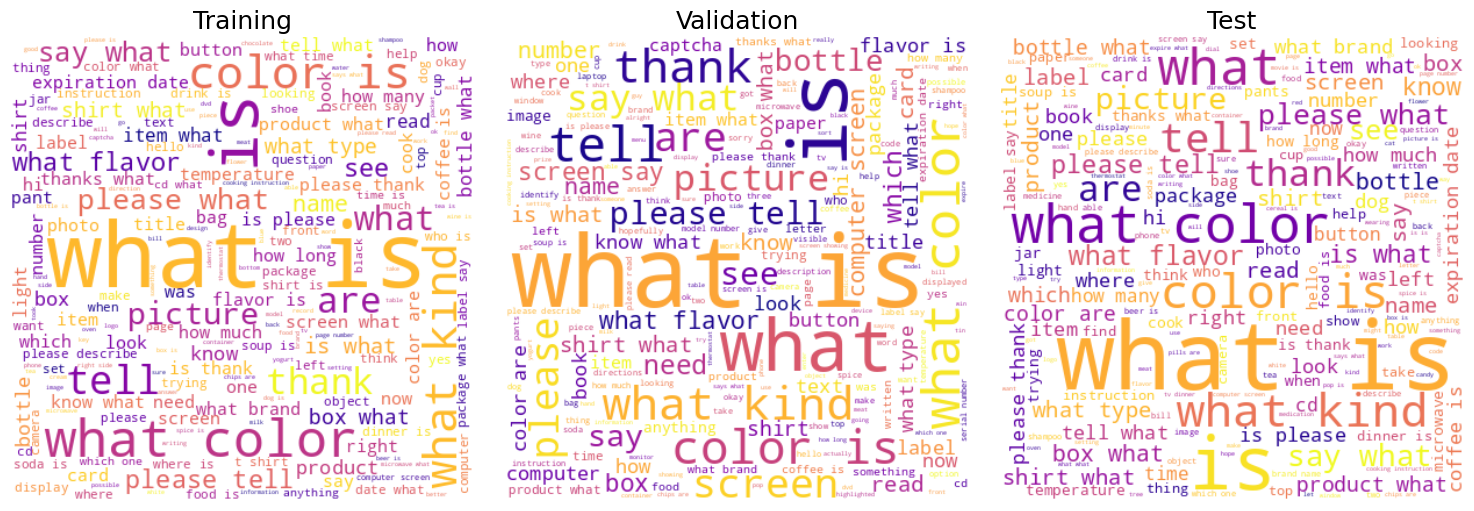

In [22]:
# Plot wordclouds of all questions for each dataframe
plot_wordclouds("question_wordclouds", train_df, val_df, test_df, 'question')

### Analysis of Answers

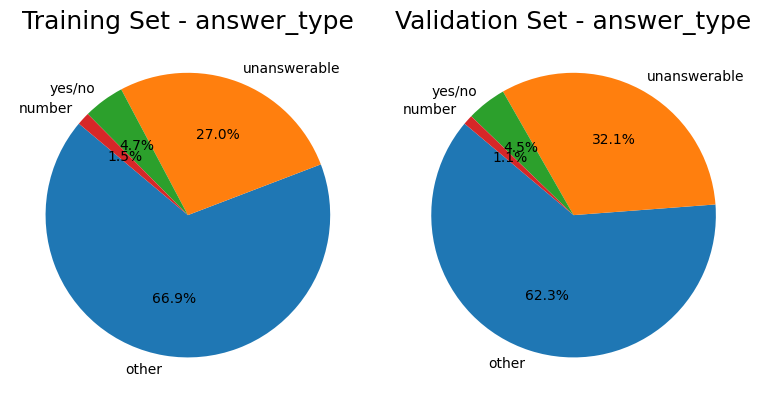

In [25]:
# Plot pie_plot for answer types in train and val dataframes
plot_pie_train_val("answer_type_pie", train_df, val_df, column='answer_type')

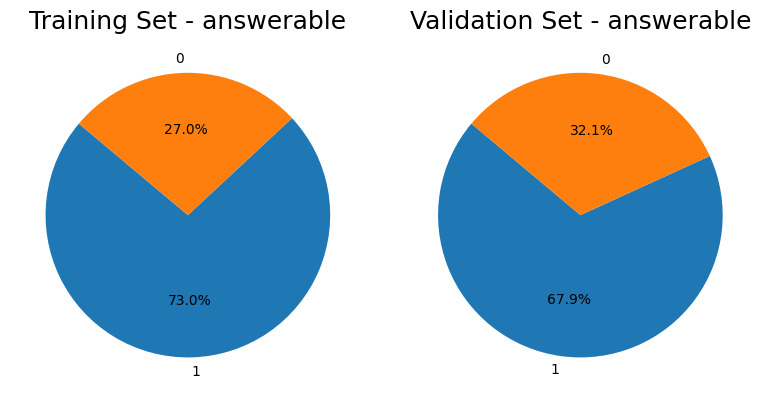

In [26]:
# Plot pie_plot for answerable in train and val dataframes
plot_pie_train_val("answerable_pie", train_df, val_df, column='answerable')

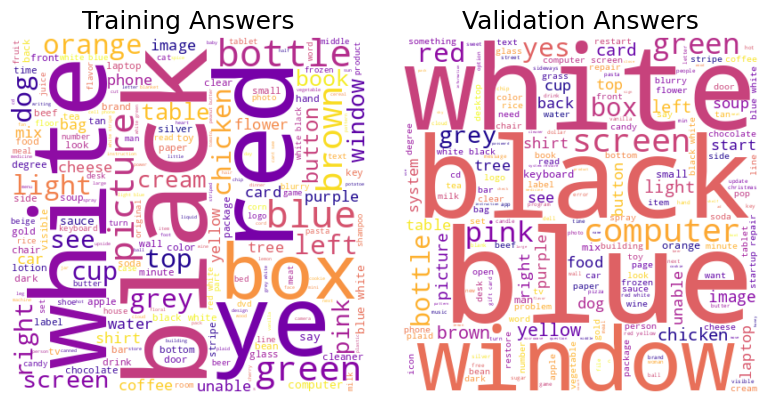

In [27]:
# Plot distinct answer wordclouds for train and val dataframes
plot_answer_wordclouds("answer_wordclouds", train_df, val_df)

### Analysis of images

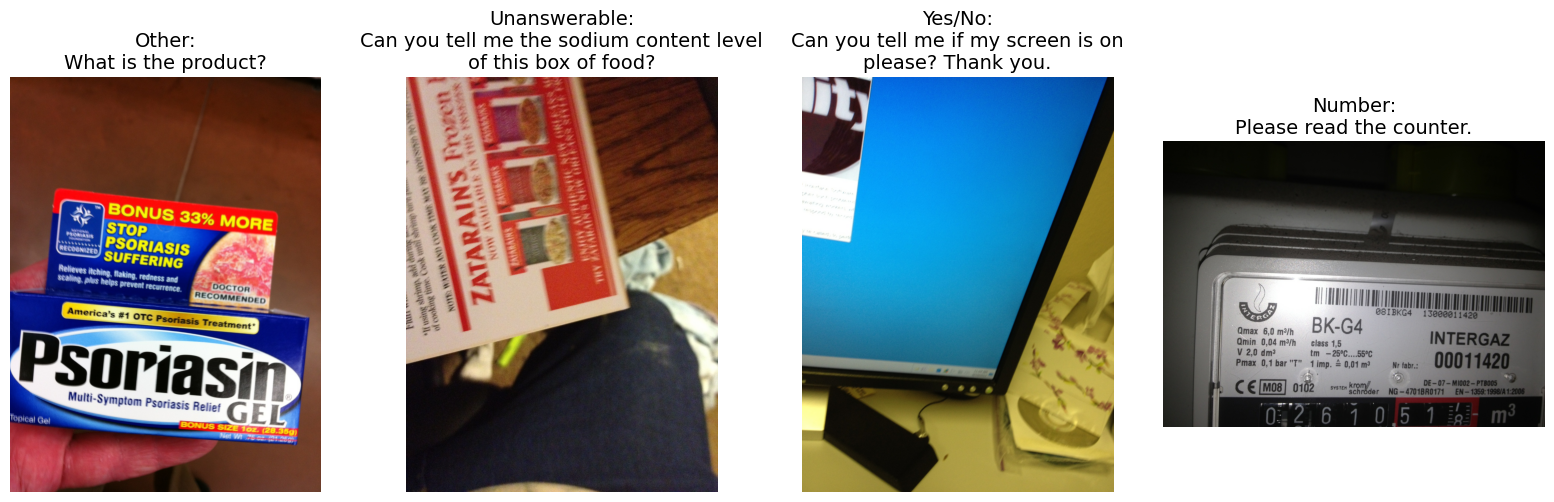

In [28]:
show_answer_type_examples("train_images", train_df, TRAIN_PATH)

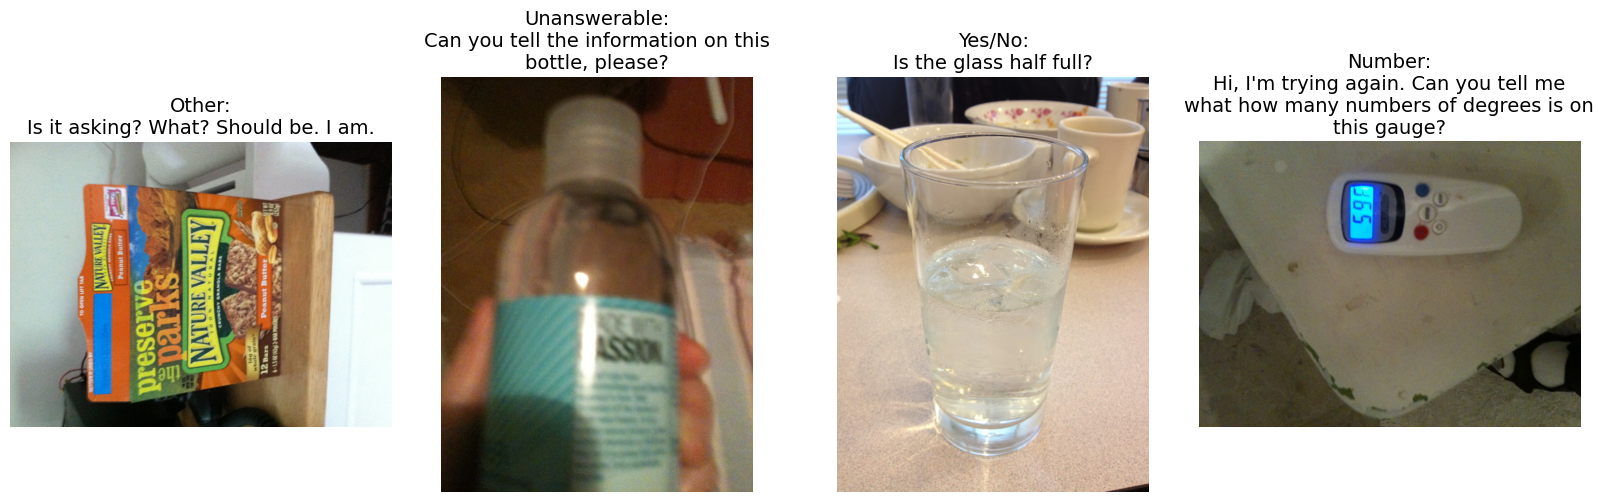

In [29]:
show_answer_type_examples("test_images", val_df, VALIDATION_PATH)